# Social Networks Analysis Project

## Import Necessary Libraries
First, we import necessary libraries used for loading, preprocessing the data, graph visualization and data evaluation.

In [1]:
# import necessary libraries

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Load Similarity Results

We load similarity results extracted from the second notebook, which will be used in this notebook.

In [2]:
# load similarity results

results = np.load("similarity_results_T1_T2.npz")

u = results["u"]
v = results["v"]

sgd = results["sgd"]
scn = results["scn"]
sjc = results["sjc"]
sa = results["sa"]
spa = results["spa"]

print(f"Number of candidate pairs: {len(u):,}")
print(f"SGD shape: {sgd.shape}")
print(f"SCN shape: {scn.shape}")
print(f"SJC shape: {sjc.shape}")
print(f"SA shape: {sa.shape}")
print(f"SPA shape: {spa.shape}")

Number of candidate pairs: 99,400
SGD shape: (99400,)
SCN shape: (99400,)
SJC shape: (99400,)
SA shape: (99400,)
SPA shape: (99400,)


## Read the data

We read the dataset so that it will be utilized during the project.
Then, we recreate the nodes from the original graphs.

In [3]:
# read the data
df = pd.read_csv(
    "sx-stackoverflow.txt",
    sep=r"\s+",
    header=None,
    names=["source", "target", "timestamp"]
)

In [4]:
# create the graphs

N = 10

tmin = df["timestamp"].min()
tmax = df["timestamp"].max()

time_points = np.linspace(tmin, tmax, N + 1)

graphs = []

for j in range(N):
    if j < N - 1:
        period_df = df[
            (df["timestamp"] >= time_points[j]) &
            (df["timestamp"] < time_points[j + 1])
        ]
    else:
        period_df = df[
            (df["timestamp"] >= time_points[j]) &
            (df["timestamp"] <= time_points[j + 1])
        ]

    G = nx.Graph()

    G.add_edges_from(
        zip(period_df["source"], period_df["target"])
    )

    G.remove_edges_from(nx.selfloop_edges(G))

    graphs.append(G)

print(f"T1 nodes: {graphs[0].number_of_nodes():,}")
print(f"T1 edges: {graphs[0].number_of_edges():,}")
print(f"T2 nodes: {graphs[1].number_of_nodes():,}")
print(f"T2 edges: {graphs[1].number_of_edges():,}")

T1 nodes: 32,888
T1 edges: 496,620
T2 nodes: 91,139
T2 edges: 1,012,026


## Define Persistent Nodes

We define the persistent nodes between T1 and T2.

In [5]:
# define persistent nodes
persistent_nodes_T1_T2 = set(graphs[0].nodes()) & set(graphs[1].nodes())

print(f"Persistent nodes T1 → T2: {len(persistent_nodes_T1_T2):,}")

Persistent nodes T1 → T2: 24,781


## Training and Testing Edges

Then, we load the edges. Since it's a new notebook, persistent edges do not exist.
We will try to recreate them from the original graphs.

In [6]:
# training and testing edges

training_edges = {
    tuple(sorted((u, v)))
    for u, v in graphs[0].edges()
    if u in persistent_nodes_T1_T2 and v in persistent_nodes_T1_T2
}

testing_edges = {
    tuple(sorted((u, v)))
    for u, v in graphs[1].edges()
    if u in persistent_nodes_T1_T2 and v in persistent_nodes_T1_T2
}

print(f"Training edges (T1): {len(training_edges):,}")
print(f"Testing edges (T2): {len(testing_edges):,}")

Training edges (T1): 453,910
Testing edges (T2): 298,615


## Connect Candidate Labels

We connect our candidate labels with the training/testing edge sets.

In [7]:
# connect candidate labels

candidate_edges = list(zip(u, v))

train_labels = np.array([
    tuple(sorted((a, b))) in training_edges
    for a, b in candidate_edges
])

test_labels = np.array([
    tuple(sorted((a, b))) in testing_edges
    for a, b in candidate_edges
])

print(f"Candidate pairs: {len(candidate_edges):,}")
print(f"Training positive pairs: {train_labels.sum():,}")
print(f"Testing positive pairs: {test_labels.sum():,}")

Candidate pairs: 99,400
Training positive pairs: 130
Testing positive pairs: 82


## Candidate-Universe Statistics

We calculate candidate-universe statistics.

In [8]:
# candidate-universe statistics

E0_size = len(candidate_edges)
E_train_size = train_labels.sum()
E_test_size = test_labels.sum()

lambda_train = E_train_size / E0_size

print(f"Candidate universe |E0|: {E0_size:,}")
print(f"Training edges |E|: {E_train_size:,}")
print(f"λ: {lambda_train:.6f}")

Candidate universe |E0|: 99,400
Training edges |E|: 130
λ: 0.001308


## SGD Score Ordering

Starting with SGD, we sort the sampled candidate pairs from most similar to least similar.
Then, we will distribute all unique values and their frequencies.

In [9]:
# SGD score ordering

sgd_order = np.argsort(-sgd)

sgd_sorted_labels = train_labels[sgd_order]
sgd_sorted_scores = sgd[sgd_order]

print("Top 10 SGD scores:")
print(sgd_sorted_scores[:10])

Top 10 SGD scores:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


In [10]:
# SGD score distribution
unique_sgd, sgd_counts = np.unique(sgd, return_counts=True)

print("SGD score distribution:")
for score, count in zip(unique_sgd, sgd_counts):
    print(f"{score:>4}: {count:,}")

SGD score distribution:
  -7: 1
  -6: 76
  -5: 1,621
  -4: 21,450
  -3: 62,973
  -2: 13,149
  -1: 130


## Compare SGD range and training edges

We then compare SGD range and training edges to see if the shortest-distance range corresponds to the T1 edges in our sample.

In [11]:
# compare SGD range and training edges

sgd_minus1 = (sgd == -1)

print(f"Pairs with SGD = -1: {sgd_minus1.sum():,}")
print(f"Training edges among them: {train_labels[sgd_minus1].sum():,}")

Pairs with SGD = -1: 130
Training edges among them: 130


In [12]:
# calculate SGD training accuracy

sgd_predicted = (sgd == -1)

TP = np.sum(sgd_predicted & train_labels)
FN = np.sum(~sgd_predicted & train_labels)

FP = np.sum(sgd_predicted & ~train_labels)
TN = np.sum(~sgd_predicted & ~train_labels)

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

ACC = lambda_train * TPR + (1 - lambda_train) * TNR

print(f"TPR: {TPR:.6f}")
print(f"TNR: {TNR:.6f}")
print(f"ACC: {ACC:.6f}")

TPR: 1.000000
TNR: 1.000000
ACC: 1.000000


## Calculate SCN Score Distribution

We calculate the score distribution of Common Neighbors (SCN) measure, before choosing its optimal range.

Then, the next step is to see how the 130 training-positive pairs are distributed across SCN values.
That will let us identify which SCN ranges contain the training edges.

In [13]:
# calculate SCN score distribution

unique_scn, scn_counts = np.unique(scn, return_counts=True)

print("SCN score distribution:")
for score, count in zip(unique_scn, scn_counts):
    print(f"{score:>4}: {count:,}")

SCN score distribution:
   0: 86,153
   1: 8,179
   2: 2,371
   3: 987
   4: 558
   5: 290
   6: 193
   7: 157
   8: 74
   9: 73
  10: 56
  11: 47
  12: 43
  13: 33
  14: 15
  15: 24
  16: 15
  17: 15
  18: 13
  19: 15
  20: 10
  21: 8
  22: 7
  23: 3
  24: 5
  26: 3
  27: 5
  28: 2
  29: 5
  30: 4
  31: 2
  32: 3
  33: 3
  35: 3
  36: 2
  37: 5
  38: 4
  40: 1
  42: 4
  43: 1
  46: 1
  49: 2
  50: 1
  62: 1
  63: 1
  66: 1
  67: 1
  99: 1


In [14]:
# SCN values of training edges

scn_train_values, scn_train_counts = np.unique(
    scn[train_labels],
    return_counts=True
)

print("SCN scores among training edges:")
for score, count in zip(scn_train_values, scn_train_counts):
    print(f"{score:>4}: {count:,}")

SCN scores among training edges:
   0: 32
   1: 20
   2: 14
   3: 3
   4: 3
   5: 4
   6: 4
   7: 6
   8: 3
   9: 5
  10: 4
  11: 4
  12: 4
  13: 3
  14: 2
  15: 2
  17: 1
  18: 1
  20: 1
  21: 1
  24: 1
  26: 1
  29: 1
  30: 1
  32: 1
  33: 1
  37: 1
  40: 1
  42: 1
  43: 1
  49: 1
  62: 1
  66: 1


In [15]:
# find the best SCN lower-bound range

scn_thresholds = np.unique(scn)

scn_results = []

for threshold in scn_thresholds:

    predicted = scn >= threshold

    TP = np.sum(predicted & train_labels)
    FN = np.sum(~predicted & train_labels)

    FP = np.sum(predicted & ~train_labels)
    TN = np.sum(~predicted & ~train_labels)

    TPR = TP / (TP + FN)
    TNR = TN / (TN + FP)

    ACC = lambda_train * TPR + (1 - lambda_train) * TNR

    scn_results.append((threshold, TPR, TNR, ACC))

scn_results = np.array(scn_results)

best_index = np.argmax(scn_results[:, 3])

print("Best SCN threshold:")
print(f"Threshold: {scn_results[best_index, 0]:.0f}")
print(f"TPR:       {scn_results[best_index, 1]:.6f}")
print(f"TNR:       {scn_results[best_index, 2]:.6f}")
print(f"ACC:       {scn_results[best_index, 3]:.6f}")

Best SCN threshold:
Threshold: 62
TPR:       0.015385
TNR:       0.999970
ACC:       0.998682


In [16]:
# SCN individual value performance

scn_value_results = []

for value in np.unique(scn):

    predicted = (scn == value)

    TP = np.sum(predicted & train_labels)
    FN = np.sum(~predicted & train_labels)

    FP = np.sum(predicted & ~train_labels)
    TN = np.sum(~predicted & ~train_labels)

    TPR = TP / (TP + FN)
    TNR = TN / (TN + FP)

    ACC = lambda_train * TPR + (1 - lambda_train) * TNR

    scn_value_results.append((value, TP, FP, TPR, TNR, ACC))

scn_value_results = np.array(scn_value_results)

best_index = np.argmax(scn_value_results[:, 5])

print("Best individual SCN value:")
print(f"SCN value: {scn_value_results[best_index, 0]:.0f}")
print(f"TP:        {scn_value_results[best_index, 1]:.0f}")
print(f"FP:        {scn_value_results[best_index, 2]:.0f}")
print(f"TPR:       {scn_value_results[best_index, 3]:.6f}")
print(f"TNR:       {scn_value_results[best_index, 4]:.6f}")
print(f"ACC:       {scn_value_results[best_index, 5]:.6f}")

Best individual SCN value:
SCN value: 40
TP:        1
FP:        0
TPR:       0.007692
TNR:       1.000000
ACC:       0.998702


In [17]:
# optimize contiguous SCN ranges

scn_values = np.unique(scn)

best_range = None
best_acc = -1

for lower in scn_values:
    for upper in scn_values:

        if lower > upper:
            continue

        predicted = (scn >= lower) & (scn <= upper)

        TP = np.sum(predicted & train_labels)
        FN = np.sum(~predicted & train_labels)

        FP = np.sum(predicted & ~train_labels)
        TN = np.sum(~predicted & ~train_labels)

        TPR = TP / (TP + FN)
        TNR = TN / (TN + FP)

        ACC = lambda_train * TPR + (1 - lambda_train) * TNR

        if ACC > best_acc:
            best_acc = ACC
            best_range = (lower, upper, TPR, TNR, ACC)

print("Best SCN range:")
print(f"Range: [{best_range[0]:.0f}, {best_range[1]:.0f}]")
print(f"TPR:   {best_range[2]:.6f}")
print(f"TNR:   {best_range[3]:.6f}")
print(f"ACC:   {best_range[4]:.6f}")

Best SCN range:
Range: [40, 40]
TPR:   0.007692
TNR:   1.000000
ACC:   0.998702


## Calculate SJC Score Distribution

We later calculate SJC Score Distribution.

In [18]:
# calculate SJC score distribution

print(f"SJC minimum: {sjc.min():.6f}")
print(f"SJC maximum: {sjc.max():.6f}")
print(f"SJC mean:    {sjc.mean():.6f}")
print(f"SJC median:  {np.median(sjc):.6f}")

SJC minimum: 0.000000
SJC maximum: 0.500000
SJC mean:    0.002054
SJC median:  0.000000


In [19]:
# SJC values of training edges

sjc_train_values, sjc_train_counts = np.unique(
    sjc[train_labels],
    return_counts=True
)

print("Number of distinct SJC values among training edges:",
      len(sjc_train_values))

print("\nFirst 20 SJC values among training edges:")
for value, count in zip(sjc_train_values[:20], sjc_train_counts[:20]):
    print(f"{value:.6f}: {count:,}")

Number of distinct SJC values among training edges: 94

First 20 SJC values among training edges:
0.000000: 32
0.002336: 1
0.003077: 1
0.003268: 1
0.003704: 1
0.004343: 1
0.005348: 1
0.005495: 1
0.005882: 1
0.006250: 1
0.006452: 1
0.006757: 1
0.006951: 1
0.007273: 1
0.007353: 1
0.008130: 2
0.008451: 1
0.009009: 1
0.009390: 1
0.009730: 1


In [20]:
# optimize SJC lower-bound range

sjc_thresholds = np.unique(sjc)

sjc_results = []

for threshold in sjc_thresholds:

    predicted = sjc >= threshold

    TP = np.sum(predicted & train_labels)
    FN = np.sum(~predicted & train_labels)

    FP = np.sum(predicted & ~train_labels)
    TN = np.sum(~predicted & ~train_labels)

    TPR = TP / (TP + FN)
    TNR = TN / (TN + FP)

    ACC = lambda_train * TPR + (1 - lambda_train) * TNR

    sjc_results.append(
        (threshold, TPR, TNR, ACC)
    )

sjc_results = np.array(sjc_results)

best_index = np.argmax(sjc_results[:, 3])

print("Best SJC lower-bound range:")
print(f"Threshold: {sjc_results[best_index, 0]:.6f}")
print(f"TPR:       {sjc_results[best_index, 1]:.6f}")
print(f"TNR:       {sjc_results[best_index, 2]:.6f}")
print(f"ACC:       {sjc_results[best_index, 3]:.6f}")

Best SJC lower-bound range:
Threshold: 0.500000
TPR:       0.000000
TNR:       0.999990
ACC:       0.998682


In [21]:
# best SJC ranges with positive predictions

sjc_candidates = []

for threshold in sjc_thresholds:

    predicted = sjc >= threshold

    if predicted.sum() == 0:
        continue

    TP = np.sum(predicted & train_labels)
    FN = np.sum(~predicted & train_labels)

    FP = np.sum(predicted & ~train_labels)
    TN = np.sum(~predicted & ~train_labels)

    TPR = TP / (TP + FN)
    TNR = TN / (TN + FP)

    ACC = lambda_train * TPR + (1 - lambda_train) * TNR

    sjc_candidates.append(
        (threshold, predicted.sum(), TP, FP, TPR, TNR, ACC)
    )

sjc_candidates = np.array(sjc_candidates)

best_index = np.argmax(sjc_candidates[:, 6])

print("Best SJC range with at least one prediction:")
print(f"Threshold:       {sjc_candidates[best_index, 0]:.6f}")
print(f"Predictions:     {sjc_candidates[best_index, 1]:.0f}")
print(f"True positives:  {sjc_candidates[best_index, 2]:.0f}")
print(f"False positives: {sjc_candidates[best_index, 3]:.0f}")
print(f"TPR:             {sjc_candidates[best_index, 4]:.6f}")
print(f"TNR:             {sjc_candidates[best_index, 5]:.6f}")
print(f"ACC:             {sjc_candidates[best_index, 6]:.6f}")

Best SJC range with at least one prediction:
Threshold:       0.500000
Predictions:     1
True positives:  0
False positives: 1
TPR:             0.000000
TNR:             0.999990
ACC:             0.998682


In [22]:
# optimize contiguous SJC ranges

sjc_train_values = np.unique(sjc[train_labels])

best_sjc = None
best_sjc_acc = -1

for lower in sjc_train_values:

    for upper in sjc_train_values:

        if lower > upper:
            continue

        predicted = (sjc >= lower) & (sjc <= upper)

        TP = np.sum(predicted & train_labels)
        FN = np.sum(~predicted & train_labels)

        FP = np.sum(predicted & ~train_labels)
        TN = np.sum(~predicted & ~train_labels)

        TPR = TP / (TP + FN)
        TNR = TN / (TN + FP)

        ACC = lambda_train * TPR + (1 - lambda_train) * TNR

        if ACC > best_sjc_acc:
            best_sjc_acc = ACC
            best_sjc = (
                lower,
                upper,
                predicted.sum(),
                TP,
                FP,
                TPR,
                TNR,
                ACC
            )

print("Best SJC range:")
print(f"Range:           [{best_sjc[0]:.6f}, {best_sjc[1]:.6f}]")
print(f"Predictions:     {best_sjc[2]:.0f}")
print(f"True positives:  {best_sjc[3]:.0f}")
print(f"False positives: {best_sjc[4]:.0f}")
print(f"TPR:             {best_sjc[5]:.6f}")
print(f"TNR:             {best_sjc[6]:.6f}")
print(f"ACC:             {best_sjc[7]:.6f}")

Best SJC range:
Range:           [0.030387, 0.030391]
Predictions:     2
True positives:  2
False positives: 0
TPR:             0.015385
TNR:             1.000000
ACC:             0.998712


In [23]:
# calculate SA score distribution

print(f"SA minimum: {sa.min():.6f}")
print(f"SA maximum: {sa.max():.6f}")
print(f"SA mean:    {sa.mean():.6f}")
print(f"SA median:  {np.median(sa):.6f}")

SA minimum: 0.000000
SA maximum: 18.326429
SA mean:    0.050739
SA median:  0.000000


In [24]:
# inspect SA values among training edges

sa_train_values, sa_train_counts = np.unique(
    sa[train_labels],
    return_counts=True
)

print("Number of distinct SA values among training edges:",
      len(sa_train_values))

print("\nFirst 20 SA values among training edges:")
for value, count in zip(sa_train_values[:20], sa_train_counts[:20]):
    print(f"{value:.6f}: {count:,}")

Number of distinct SA values among training edges: 99

First 20 SA values among training edges:
0.000000: 32
0.125037: 1
0.152025: 1
0.159084: 1
0.159226: 1
0.159464: 1
0.159902: 1
0.167469: 1
0.175840: 1
0.191558: 1
0.194712: 1
0.200112: 1
0.216679: 1
0.217147: 1
0.223919: 1
0.226304: 1
0.230213: 1
0.240449: 1
0.248425: 1
0.292608: 1


In [25]:
# find training-optimal SA range

sa_train_values = np.unique(sa[train_labels])

best_sa = None
best_sa_acc = -1

for lower in sa_train_values:

    for upper in sa_train_values:

        if lower > upper:
            continue

        predicted = (sa >= lower) & (sa <= upper)

        TP = np.sum(predicted & train_labels)
        FN = np.sum(~predicted & train_labels)

        FP = np.sum(predicted & ~train_labels)
        TN = np.sum(~predicted & ~train_labels)

        TPR = TP / (TP + FN)
        TNR = TN / (TN + FP)

        ACC = lambda_train * TPR + (1 - lambda_train) * TNR

        if ACC > best_sa_acc:
            best_sa_acc = ACC
            best_sa = (
                lower,
                upper,
                predicted.sum(),
                TP,
                FP,
                TPR,
                TNR,
                ACC
            )

print("Best SA range:")
print(f"Range:           [{best_sa[0]:.6f}, {best_sa[1]:.6f}]")
print(f"Predictions:     {best_sa[2]:.0f}")
print(f"True positives:  {best_sa[3]:.0f}")
print(f"False positives: {best_sa[4]:.0f}")
print(f"TPR:             {best_sa[5]:.6f}")
print(f"TNR:             {best_sa[6]:.6f}")
print(f"ACC:             {best_sa[7]:.6f}")

Best SA range:
Range:           [1.646894, 1.647013]
Predictions:     2
True positives:  2
False positives: 0
TPR:             0.015385
TNR:             1.000000
ACC:             0.998712


In [26]:
# SPA score distribution

print(f"SPA minimum: {spa.min():.0f}")
print(f"SPA maximum: {spa.max():.0f}")
print(f"SPA mean:    {spa.mean():.2f}")
print(f"SPA median:  {np.median(spa):.0f}")

SPA minimum: 1
SPA maximum: 459000
SPA mean:    1236.98
SPA median:  150


In [27]:
# SPA values among training edges

spa_train_values, spa_train_counts = np.unique(
    spa[train_labels],
    return_counts=True
)

print("Number of distinct SPA values among training edges:",
      len(spa_train_values))

print("\nFirst 20 SPA values among training edges:")
for value, count in zip(spa_train_values[:20], spa_train_counts[:20]):
    print(f"{value:.0f}: {count:,}")

Number of distinct SPA values among training edges: 130

First 20 SPA values among training edges:
113: 1
195: 1
220: 1
222: 1
264: 1
308: 1
328: 1
339: 1
344: 1
357: 1
450: 1
483: 1
490: 1
588: 1
667: 1
675: 1
790: 1
840: 1
864: 1
884: 1


In [28]:
# find training-optimal SPA range

spa_train_values = np.unique(spa[train_labels])

best_spa = None
best_spa_acc = -1

for lower in spa_train_values:

    for upper in spa_train_values:

        if lower > upper:
            continue

        predicted = (spa >= lower) & (spa <= upper)

        TP = np.sum(predicted & train_labels)
        FN = np.sum(~predicted & train_labels)

        FP = np.sum(predicted & ~train_labels)
        TN = np.sum(~predicted & ~train_labels)

        TPR = TP / (TP + FN)
        TNR = TN / (TN + FP)

        ACC = lambda_train * TPR + (1 - lambda_train) * TNR

        if ACC > best_spa_acc:
            best_spa_acc = ACC
            best_spa = (
                lower,
                upper,
                predicted.sum(),
                TP,
                FP,
                TPR,
                TNR,
                ACC
            )

print("Best SPA range:")
print(f"Range:           [{best_spa[0]:.0f}, {best_spa[1]:.0f}]")
print(f"Predictions:     {best_spa[2]:.0f}")
print(f"True positives:  {best_spa[3]:.0f}")
print(f"False positives: {best_spa[4]:.0f}")
print(f"TPR:             {best_spa[5]:.6f}")
print(f"TNR:             {best_spa[6]:.6f}")
print(f"ACC:             {best_spa[7]:.6f}")

Best SPA range:
Range:           [49856, 50105]
Predictions:     2
True positives:  2
False positives: 0
TPR:             0.015385
TNR:             1.000000
ACC:             0.998712


## Evaluate all optimal ranges on T2

We later evaluate all optimal ranges on T2, since accuracy is misleading in this case.
Only 130 of 99,400 sampled candidate pairs are training positives.

In [29]:
# evaluate fixed training-optimal ranges

pred_sgd = (sgd >= -1) & (sgd <= -1)
pred_scn = (scn >= 40) & (scn <= 40)
pred_sjc = (sjc >= 0.030387) & (sjc <= 0.030391)
pred_sa = (sa >= 1.646894) & (sa <= 1.647013)
pred_spa = (spa >= 49856) & (spa <= 50105)


def evaluate_test(predicted, labels, lambda_value):
    
    TP = np.sum(predicted & labels)
    FN = np.sum(~predicted & labels)

    FP = np.sum(predicted & ~labels)
    TN = np.sum(~predicted & ~labels)

    TPR = TP / (TP + FN)
    TNR = TN / (TN + FP)

    ACC = lambda_value * TPR + (1 - lambda_value) * TNR

    return TP, FP, TPR, TNR, ACC


results_test = {}

for name, predicted in [
    ("SGD", pred_sgd),
    ("SCN", pred_scn),
    ("SJC", pred_sjc),
    ("SA", pred_sa),
    ("SPA", pred_spa)
]:
    
    results_test[name] = evaluate_test(
        predicted,
        test_labels,
        E_test_size / E0_size
    )


for name, values in results_test.items():
    TP, FP, TPR, TNR, ACC = values
    
    print(f"{name}:")
    print(f"  TP:  {TP}")
    print(f"  FP:  {FP}")
    print(f"  TPR: {TPR:.6f}")
    print(f"  TNR: {TNR:.6f}")
    print(f"  ACC: {ACC:.6f}")
    print()

SGD:
  TP:  7
  FP:  123
  TPR: 0.085366
  TNR: 0.998762
  ACC: 0.998008

SCN:
  TP:  0
  FP:  1
  TPR: 0.000000
  TNR: 0.999990
  ACC: 0.999165

SJC:
  TP:  0
  FP:  1
  TPR: 0.000000
  TNR: 0.999990
  ACC: 0.999165

SA:
  TP:  0
  FP:  2
  TPR: 0.000000
  TNR: 0.999980
  ACC: 0.999155

SPA:
  TP:  1
  FP:  1
  TPR: 0.012195
  TNR: 0.999990
  ACC: 0.999175



In [30]:
# check SPA test performance

TP, FP, TPR, TNR, ACC = results_test["SPA"]

print("SPA:")
print(f"  TP:  {TP}")
print(f"  FP:  {FP}")
print(f"  TPR: {TPR:.6f}")
print(f"  TNR: {TNR:.6f}")
print(f"  ACC: {ACC:.6f}")

SPA:
  TP:  1
  FP:  1
  TPR: 0.012195
  TNR: 0.999990
  ACC: 0.999175


## Create the final results table

To finish model evaluation, we create the final results table.
We then save the results in a clean dataframe.

In [31]:
# create final results

final_results = []

training_results = {
    "SGD": (1.000000, 1.000000, 1.000000),
    "SCN": (0.007692, 1.000000, 0.998702),
    "SJC": (0.015385, 1.000000, 0.998712),
    "SA":  (0.015385, 1.000000, 0.998712),
    "SPA": (0.015385, 1.000000, 0.998712)
}

ranges = {
    "SGD": "[-1, -1]",
    "SCN": "[40, 40]",
    "SJC": "[0.030387, 0.030391]",
    "SA": "[1.646894, 1.647013]",
    "SPA": "[49856, 50105]"
}

for name in ["SGD", "SCN", "SJC", "SA", "SPA"]:
    
    train_TPR, train_TNR, train_ACC = training_results[name]
    test_TP, test_FP, test_TPR, test_TNR, test_ACC = results_test[name]
    
    final_results.append({
        "Measure": name,
        "Optimal Range": ranges[name],
        "Train TPR": train_TPR,
        "Train TNR": train_TNR,
        "Train ACC": train_ACC,
        "Test TP": test_TP,
        "Test FP": test_FP,
        "Test TPR": test_TPR,
        "Test TNR": test_TNR,
        "Test ACC": test_ACC
    })

final_results_df = pd.DataFrame(final_results)

final_results_df

,Measure,Optimal Range,Train TPR,Train TNR,Train ACC,Test TP,Test FP,Test TPR,Test TNR,Test ACC
0,SGD,"[-1, -1]",1.000000,1.0,1.000000,7,123,0.085366,0.998762,0.998008
1,SCN,"[40, 40]",0.007692,1.0,0.998702,0,1,0.000000,0.999990,0.999165
2,SJC,"[0.030387, 0.030391]",0.015385,1.0,0.998712,0,1,0.000000,0.999990,0.999165
3,SA,"[1.646894, 1.647013]",0.015385,1.0,0.998712,0,2,0.000000,0.999980,0.999155
4,SPA,"[49856, 50105]",0.015385,1.0,0.998712,1,1,0.012195,0.999990,0.999175


In [32]:
# display key results

print(
    final_results_df[
        [
            "Measure",
            "Optimal Range",
            "Train ACC",
            "Test TPR",
            "Test TNR",
            "Test ACC"
        ]
    ].to_string(index=False)
)

Measure        Optimal Range  Train ACC  Test TPR  Test TNR  Test ACC
    SGD             [-1, -1]   1.000000  0.085366  0.998762  0.998008
    SCN             [40, 40]   0.998702  0.000000  0.999990  0.999165
    SJC [0.030387, 0.030391]   0.998712  0.000000  0.999990  0.999165
     SA [1.646894, 1.647013]   0.998712  0.000000  0.999980  0.999155
    SPA       [49856, 50105]   0.998712  0.012195  0.999990  0.999175


## Plot training vs. testing accuracy

We plot the main comparison figure.

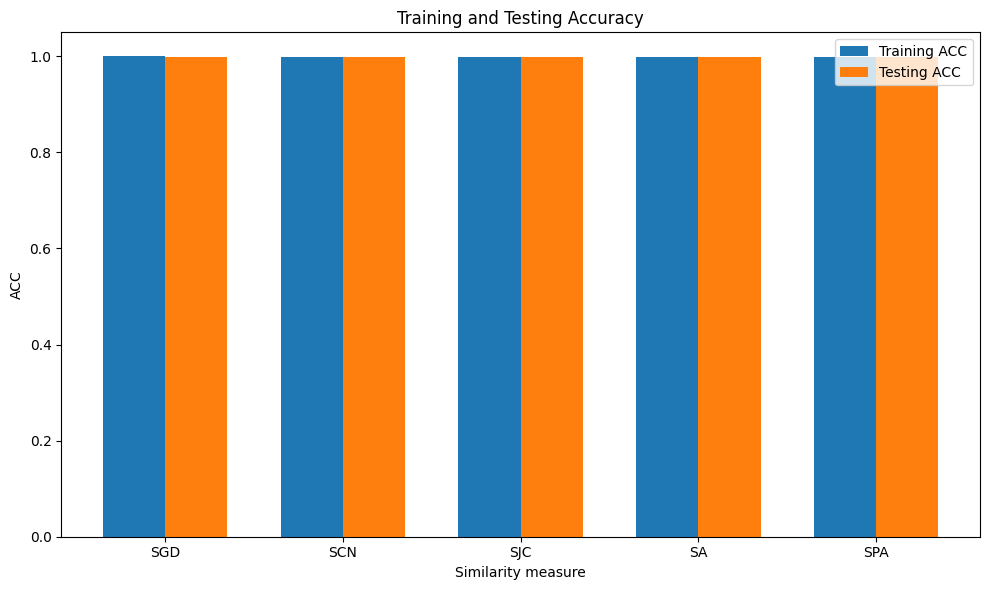

In [33]:
# plot training vs. testing accuracy

x = np.arange(len(final_results_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    final_results_df["Train ACC"],
    width,
    label="Training ACC"
)

plt.bar(
    x + width / 2,
    final_results_df["Test ACC"],
    width,
    label="Testing ACC"
)

plt.xticks(
    x,
    final_results_df["Measure"]
)

plt.ylabel("ACC")
plt.xlabel("Similarity measure")
plt.title("Training and Testing Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

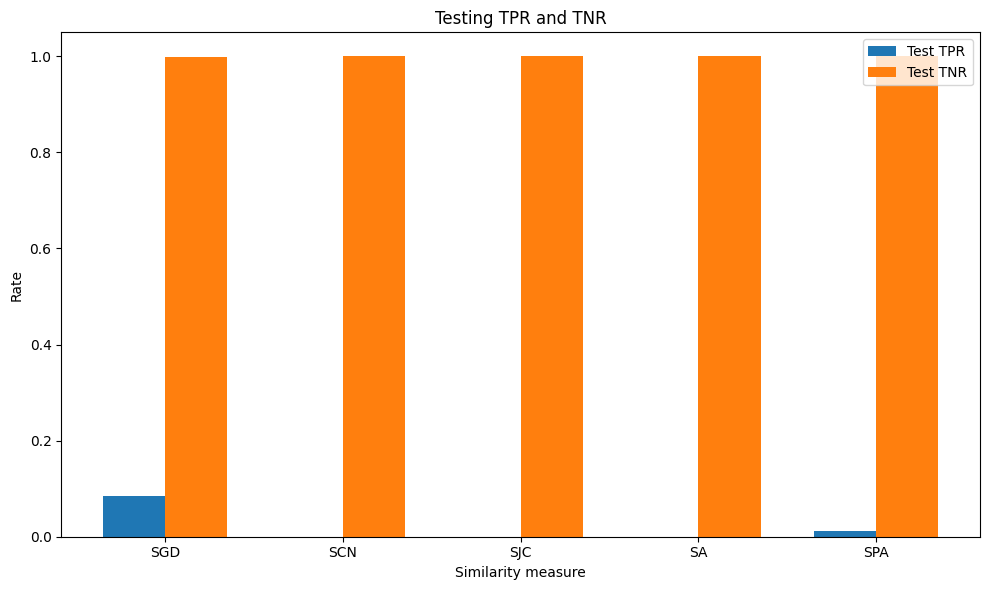

In [34]:
# plot TPR and TNR

x = np.arange(len(final_results_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    final_results_df["Test TPR"],
    width,
    label="Test TPR"
)

plt.bar(
    x + width / 2,
    final_results_df["Test TNR"],
    width,
    label="Test TNR"
)

plt.xticks(
    x,
    final_results_df["Measure"]
)

plt.ylabel("Rate")
plt.xlabel("Similarity measure")
plt.title("Testing TPR and TNR")
plt.legend()

plt.tight_layout()
plt.show()

## Save Results

We save final results for future use/deployment.

In [35]:
# save final results

final_results_df.to_csv(
    "part3_link_prediction_results.csv",
    index=False
)

print("Results saved to part3_link_prediction_results.csv")

Results saved to part3_link_prediction_results.csv
